In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import spiceypy as spice

In [6]:
# SPICE test
spice.tkvrsn('TOOLKIT')

'CSPICE_N0067'

Import SPICE user Lib

In [7]:
import sys

# import SPICE user lib
sys.path.append('../lib/')
import voyager_spice_lib as vy_lib
import my_spice_lib as my_lib

Load SPICE kernels

In [8]:
# load SPICE ketnels
vy_lib.spice_ini()

True


Overall S/C orbit

In [9]:
# set date/time
utctim = '1977-09-06T00:00:00'    # start date/time
et_ex = spice.str2et(utctim)      # seconds
dt = 60*60*24   # time step [second]
nd = 365*50     # number of data
et = et_ex + dt * np.arange(0, nd)

# calculate target position with spice
x, y, z, r, lat, lon = my_lib.get_pos_xref(
    et, ref='IAU_SUN', tar='VOYAGER 2', org='SUN', x_ref='URANUS BARYCENTER', corr='LT+S')


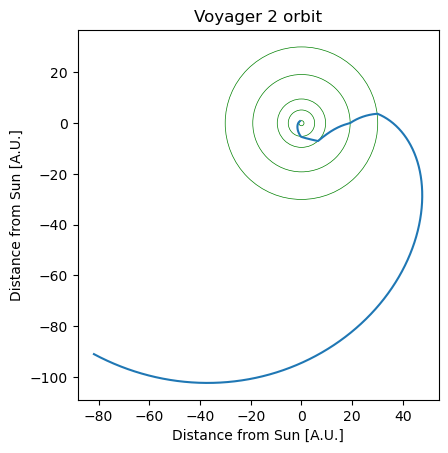

In [10]:
from astropy.constants import au

fig,ax = plt.subplots()

# plot spacecraft orbit
au_km = au*1e-3
plt.plot(x/au_km, y/au_km)

# plot planet orbits (earth, jupiter, saturn, uranus, and neptune)
c_e = patches.Circle( xy=(0,0), radius=1.0,     edgecolor='green', facecolor='none', linewidth=0.5)
c_j = patches.Circle( xy=(0,0), radius=5.2030,  edgecolor='green', facecolor='none', linewidth=0.5)
c_s = patches.Circle( xy=(0,0), radius=9.5388,  edgecolor='green', facecolor='none', linewidth=0.5)
c_u = patches.Circle( xy=(0,0), radius=19.1914, edgecolor='green', facecolor='none', linewidth=0.5)
c_n = patches.Circle( xy=(0,0), radius=30.0611, edgecolor='green', facecolor='none', linewidth=0.5)
ax.add_patch(c_e)
ax.add_patch(c_j)
ax.add_patch(c_s)
ax.add_patch(c_u)
ax.add_patch(c_n)

plt.title('Voyager 2 orbit')
plt.xlabel('Distance from Sun [A.U.]')
plt.ylabel('Distance from Sun [A.U.]')
ax.set_aspect('equal')
plt.show()


S/C orbit around Uranus

In [11]:
# set date/time
utctim = '1985-12-16T00:00:00'    # start date/time
et_ex = spice.str2et(utctim)      # seconds
dt = 60*60    # time step [second]
nd = 24*30*2  # number of data
et = et_ex + dt * np.arange(0, nd)

# calculate target position with spice
x, y, z, r, lat, lon = my_lib.get_pos_xref(
    et, ref='IAU_SUN', tar='VOYAGER 2', org='URANUS BARYCENTER', x_ref='SUN', corr='LT+S')


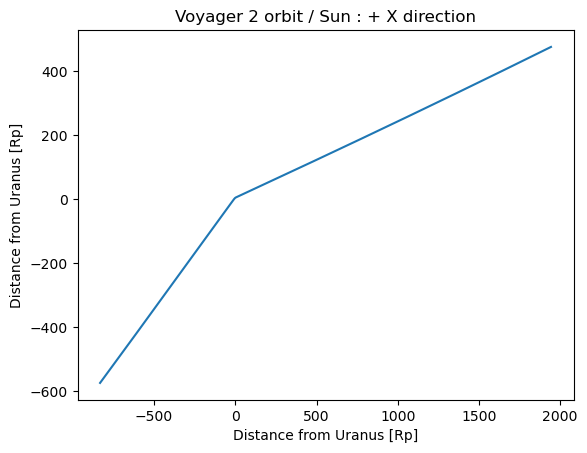

In [12]:
# plot
rp = 25362.0  # [km]
plt.plot(x/rp, y/rp)
plt.title('Voyager 2 orbit / Sun : + X direction')
plt.xlabel('Distance from Uranus [Rp]')
plt.ylabel('Distance from Uranus [Rp]')
plt.show()

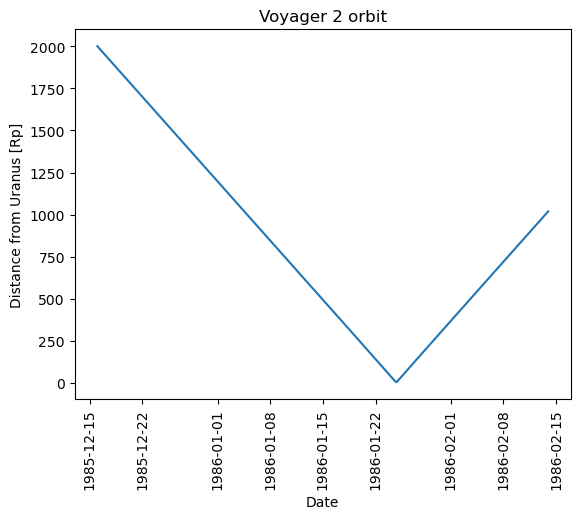

In [13]:
# plot
td = spice.et2datetime(et)
plt.plot(td, r/rp)
plt.title('Voyager 2 orbit')
plt.xlabel('Date')
plt.ylabel('Distance from Uranus [Rp]')
plt.xticks(rotation=90)
plt.show()